In [1]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df=pd.read_csv("iphone_purchase.csv")

In [3]:
df

,Gender,Age,Salary,Purchase Iphone
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0
...,...,...,...,...
395,Female,46,41000,1
396,Male,51,23000,1
397,Female,50,20000,1
398,Male,36,33000,0


In [4]:
from sklearn.preprocessing import LabelEncoder
l=LabelEncoder()
df['Gender'] = l.fit_transform(df['Gender'])

In [5]:
X=df.copy()
X.drop("Purchase Iphone",inplace=True,axis=1)


In [6]:
y=df["Purchase Iphone"]

In [7]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.3,random_state=42)

In [8]:
model=DecisionTreeClassifier(criterion="entropy",random_state=42)



In [9]:
model.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [10]:
y_pred=model.predict(X_test)

In [11]:
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))


0.8583333333333333
[[64  9]
 [ 8 39]]
              precision    recall  f1-score   support

           0       0.89      0.88      0.88        73
           1       0.81      0.83      0.82        47

    accuracy                           0.86       120
   macro avg       0.85      0.85      0.85       120
weighted avg       0.86      0.86      0.86       120



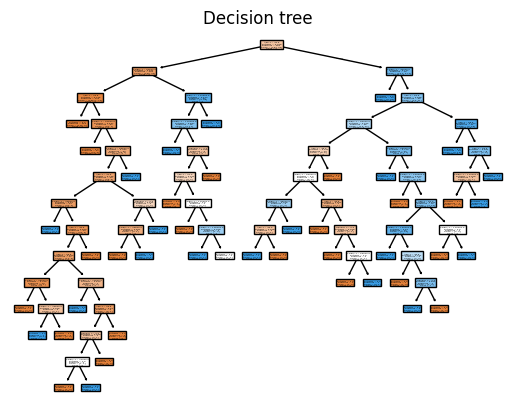

In [12]:
plot_tree(model,feature_names=X.columns,class_names=[str(i) for i in model.classes_],filled=True)
plt.title("Decision tree")
plt.show()

In [13]:
depth = model.get_depth()
print("Depth of tree:", depth)

Depth of tree: 13


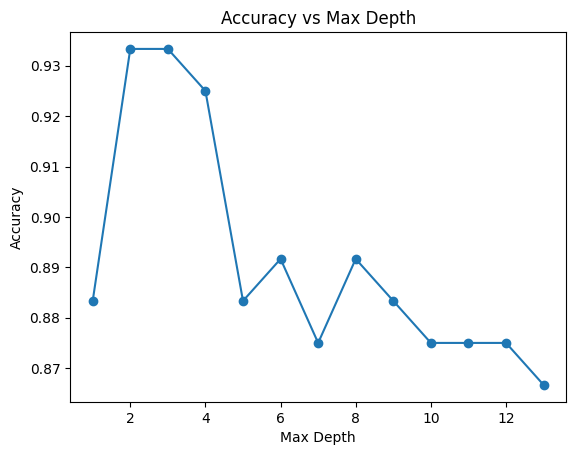

In [14]:
depths = range(1, 14)
accuracies = []

for i in depths:
    model = DecisionTreeClassifier(max_depth=i, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

plt.plot(depths, accuracies, marker='o')
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Max Depth")
plt.show()

In [15]:
model=DecisionTreeClassifier(random_state=42)


In [16]:
model.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [17]:
y_pred1=model.predict(X_test)

In [18]:
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(classification_report(y_test,y_pred1))


0.8666666666666667
[[64  9]
 [ 7 40]]
              precision    recall  f1-score   support

           0       0.90      0.88      0.89        73
           1       0.82      0.85      0.83        47

    accuracy                           0.87       120
   macro avg       0.86      0.86      0.86       120
weighted avg       0.87      0.87      0.87       120



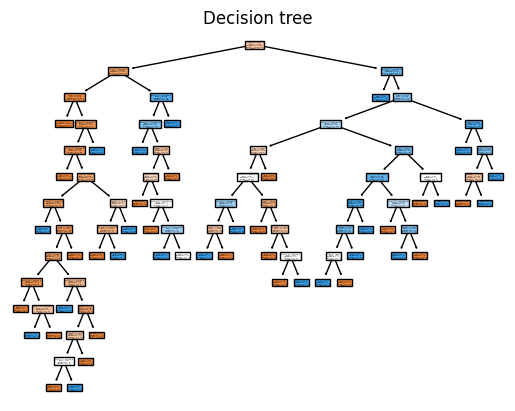

In [19]:
plot_tree(model,feature_names=X.columns,class_names=[str(i) for i in model.classes_],filled=True)
plt.title("Decision tree")
plt.show()

In [20]:
depth = model.get_depth()
print("Depth of tree:", depth)

Depth of tree: 13
